<a href="https://colab.research.google.com/github/candido05/Federated-Learning/blob/main/FL_TESTE_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Criar o grafo
G = nx.Graph()

# Adicionar nós
clientes = ["Cliente 1", "Cliente 2", "Cliente 3", "Cliente 4", "Cliente 5",
            "Cliente 6", "Cliente 7", "Cliente 8", "Cliente 9", "Cliente 10"]
servidor = "Servidor"

G.add_node(servidor)
for cliente in clientes:
    G.add_node(cliente)

# Adicionar arestas com pesos específicos (conforme a imagem fornecida)
edges_with_weights = [
    ("Servidor", "Cliente 1", 30),
    ("Servidor", "Cliente 2", 20),
    ("Servidor", "Cliente 7", 18),
    ("Cliente 1", "Cliente 2", 10),
    ("Cliente 1", "Cliente 3", 27),
    ("Cliente 2", "Cliente 5", 11),
    ("Cliente 3", "Cliente 4", 16),
    ("Cliente 4", "Cliente 5", 25),
    ("Cliente 5", "Cliente 6", 31),
    ("Cliente 7", "Cliente 6", 13),
    ("Cliente 7", "Cliente 8", 14),
    ("Cliente 8", "Cliente 6", 19),
    ("Cliente 8", "Cliente 10", 17),
    ("Cliente 9", "Cliente 10", 35),
    ("Servidor", "Cliente 9", 15),
    ("Servidor", "Cliente 10", 27)
]

# Adicionar as arestas com os pesos ao grafo
for edge in edges_with_weights:
    G.add_edge(edge[0], edge[1], weight=edge[2])

# Posicionamento dos nós (ajuste manual para uma disposição semelhante à imagem)
pos = {
    "Servidor": (0, 0),
    "Cliente 1": (-1, 1),
    "Cliente 2": (-1.5, 0.5),
    "Cliente 3": (-2, 1),
    "Cliente 4": (-2.5, 0.5),
    "Cliente 5": (-2, 0),
    "Cliente 6": (-1.5, -0.5),
    "Cliente 7": (-1, -1),
    "Cliente 8": (0, -1),
    "Cliente 9": (1, 1),
    "Cliente 10": (1, -1)
}

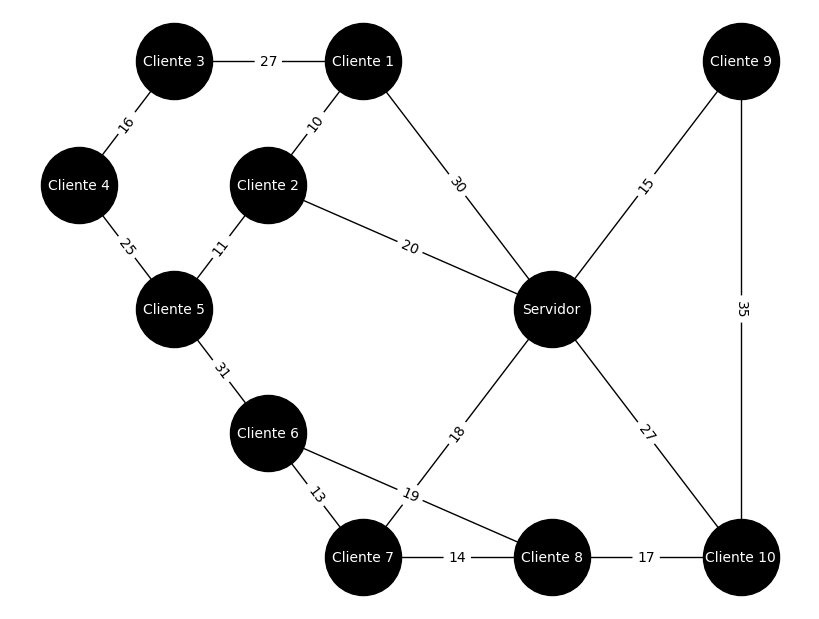

In [ ]:
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="black", font_size=10, edge_color="black", font_color="white")
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): d['weight'] for u, v, d in G.edges(data=True)}, font_size=10)

plt.show()

## FL

In [ ]:
!pip install -q flwr[simulation] flwr-datasets[vision] torch torchvision matplotlib

In [ ]:
from collections import OrderedDict
from typing import List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from datasets.utils.logging import disable_progress_bar
from torch.utils.data import DataLoader

import flwr
from flwr.client import Client, ClientApp, NumPyClient
from flwr.common import Metrics, Context
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg, FedOpt, FedAvgM, FedProx,  FedAdagrad, FedAdam, FedMedian
from flwr.simulation import run_simulation
from flwr_datasets import FederatedDataset
from flwr.common import ndarrays_to_parameters, NDArrays, Scalar, Context

In [ ]:
DEVICE = torch.device("cpu")
print(f"Training {DEVICE}")
print(f"Flower {flwr.__version__} / PyTorch {torch.__version__}")
disable_progress_bar()

Training cpu
Flower 1.12.0 / PyTorch 2.5.0+cu121


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
NUM_CLIENTS = 10
BATCH_SIZE = 32

def load_datasets(partition_id: int):
    fds = FederatedDataset(dataset="cifar10", partitioners={"train": NUM_CLIENTS})
    partition = fds.load_partition(partition_id)
    # Divisão do dataset em 80% para treinamento e 20% para testes
    partition_train_test = partition.train_test_split(test_size=0.2, seed=42)
    pytorch_transforms = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    def apply_transforms(batch):
        # Em vez de passar transformações para CIFAR10(..., transform=transform)
        # é usada esta função para dataset.with_transform(apply_transforms)
        # onde o objeto de transform é exatamente o mesmo
        batch["img"] = [pytorch_transforms(img) for img in batch["img"]]
        return batch

    # Criando train/val para cada partição e envolva-o no DataLoader
    partition_train_test = partition_train_test.with_transform(apply_transforms)
    trainloader = DataLoader(
        partition_train_test["train"], batch_size=BATCH_SIZE, shuffle=True
    )
    valloader = DataLoader(partition_train_test["test"], batch_size=BATCH_SIZE)
    testset = fds.load_split("test").with_transform(apply_transforms)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE)
    return trainloader, valloader, testloader

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


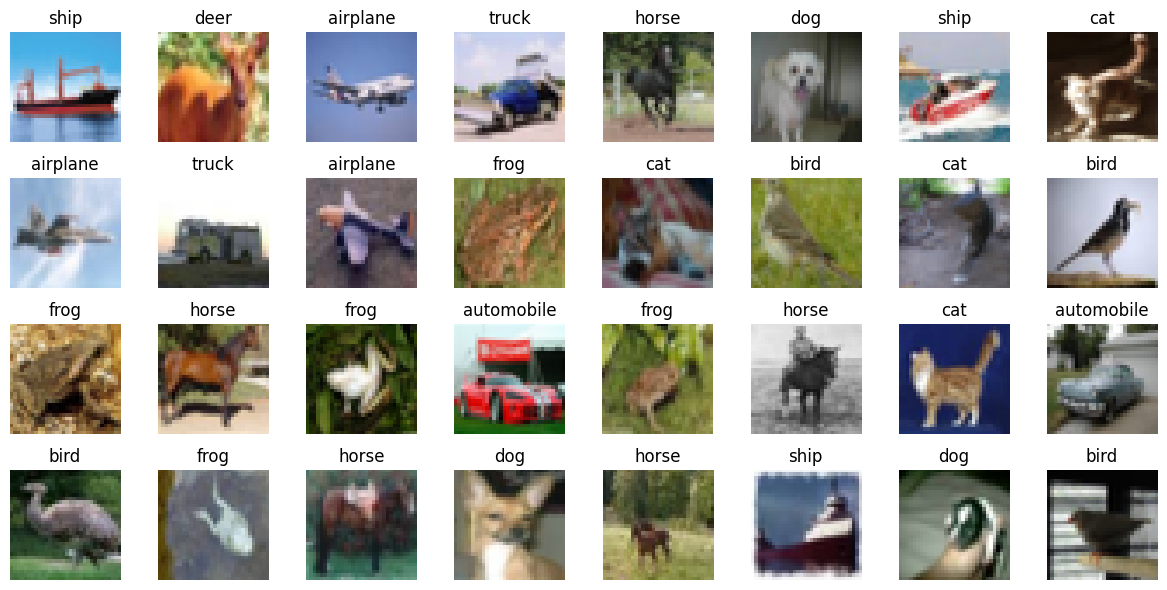

In [ ]:
# olhando o primeiro lote de imagens e rótulos no primeiro conjunto de treinamento

trainloader, _, _ = load_datasets(partition_id=0)
batch = next(iter(trainloader))
images, labels = batch["img"], batch["label"]
images = images.permute(0, 2, 3, 1).numpy()
images = images / 2 + 0.5

fig, axs = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axs.flat):
    ax.imshow(images[i])
    ax.set_title(trainloader.dataset.features["label"].int2str([labels[i]])[0])
    ax.axis("off")

fig.tight_layout()
plt.show()

### Treinamento local

In [ ]:
class Net(nn.Module):
    def __init__(self) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


def get_parameters(net) -> List[np.ndarray]:
    return [val.cpu().numpy() for _, val in net.state_dict().items()]


def set_parameters(net, parameters: List[np.ndarray]):
    params_dict = zip(net.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.Tensor(v) for k, v in params_dict})
    net.load_state_dict(state_dict, strict=True)


def train(net, trainloader, epochs: int):
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters())
    net.train()
    for epoch in range(epochs):
        correct, total, epoch_loss = 0, 0, 0.0
        for batch in trainloader:
            images, labels = batch["img"], batch["label"]
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = net(images)
            loss = criterion(net(images), labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss
            total += labels.size(0)
            correct += (torch.max(outputs.data, 1)[1] == labels).sum().item()
        epoch_loss /= len(trainloader.dataset)
        epoch_acc = correct / total
        print(f"Epoch {epoch+1}: train loss {epoch_loss}, accuracy {epoch_acc}")


def test(net, testloader):
    criterion = torch.nn.CrossEntropyLoss()
    correct, total, loss = 0, 0, 0.0
    net.eval()
    with torch.no_grad():
        for batch in testloader:
            images, labels = batch["img"], batch["label"]
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    loss /= len(testloader.dataset)
    accuracy = correct / total
    return loss, accuracy

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


## Cliente

In [ ]:
NUM_PARTITIONS = 10
BATCH_SIZE = 32


def load_datasets(partition_id: int, num_partitions: int):
    fds = FederatedDataset(dataset="cifar10", partitioners={"train": num_partitions})
    partition = fds.load_partition(partition_id)
    partition_train_test = partition.train_test_split(test_size=0.2, seed=42)
    pytorch_transforms = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    def apply_transforms(batch):
        batch["img"] = [pytorch_transforms(img) for img in batch["img"]]
        return batch

    partition_train_test = partition_train_test.with_transform(apply_transforms)
    trainloader = DataLoader(
        partition_train_test["train"], batch_size=BATCH_SIZE, shuffle=True
    )
    valloader = DataLoader(partition_train_test["test"], batch_size=BATCH_SIZE)
    testset = fds.load_split("test").with_transform(apply_transforms)
    testloader = DataLoader(testset, batch_size=BATCH_SIZE)
    return trainloader, valloader, testloader

In [ ]:
class FlowerClient(NumPyClient):
    def __init__(self, partition_id, net, trainloader, valloader):
        self.partition_id = partition_id
        self.net = net
        self.trainloader = trainloader
        self.valloader = valloader

    def get_parameters(self, config):
        print(f"[Client {self.partition_id}] get_parameters")
        return get_parameters(self.net)

    def fit(self, parameters, config):
        print(f"[Client {self.partition_id}] fit, config: {config}")
        set_parameters(self.net, parameters)
        train(self.net, self.trainloader, epochs=1)
        return get_parameters(self.net), len(self.trainloader), {}

    def evaluate(self, parameters, config):
        print(f"[Client {self.partition_id}] evaluate, config: {config}")
        set_parameters(self.net, parameters)
        loss, accuracy = test(self.net, self.valloader)
        return float(loss), len(self.valloader), {"accuracy": float(accuracy)}


def client_fn(context: Context) -> Client:
    net = Net().to(DEVICE)
    partition_id = context.node_config["partition-id"]
    num_partitions = context.node_config["num-partitions"]

    trainloader, valloader, _ = load_datasets(partition_id, num_partitions)
    return FlowerClient(partition_id, net, trainloader, valloader).to_client()

client = ClientApp(client_fn=client_fn)

In [ ]:
# Cria uma instancia do modelo e pega os parametros
params = get_parameters(Net())

# server_fn que retorna os componentes necessários para o servido

def server_fn(context: Context) -> ServerAppComponents:
    strategy = FedAvg(
        fraction_fit=1,
        fraction_evaluate=1,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(
            params
        ),  # parametros iniciais do modelo
    )

    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

server = ServerApp(server_fn=server_fn)

In [ ]:
backend_config = {"client_resources": None}
if DEVICE.type == "cuda":
    backend_config = {"client_resources": {"num_gpus": 1}}

run_simulation(
    server_app=server,
    client_app=client,
    num_supernodes=NUM_PARTITIONS,
    backend_config=backend_config,
)

DEBUG:flwr:Asyncio event loop already running.
INFO :      Starting Flower ServerApp, config: num_rounds=3, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 5 clients (out of 10)
(pid=20253) 2024-11-08 02:07:00.003375: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=20253) 2024-11-08 02:07:00.027831: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=20253) 2024-11-08 02:07:00.035157: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to regi

(ClientAppActor pid=20253) [Client 1] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.0647607073187828, accuracy 0.22175
(ClientAppActor pid=20253) [Client 2] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.06576317548751831, accuracy 0.21325
(ClientAppActor pid=20253) [Client 3] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.06502854079008102, accuracy 0.221
(ClientAppActor pid=20253) [Client 4] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.06593570858240128, accuracy 0.22025
(ClientAppActor pid=20253) [Client 7] fit, config: {}


INFO :      aggregate_fit: received 5 results and 0 failures
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


(ClientAppActor pid=20253) Epoch 1: train loss 0.06512130051851273, accuracy 0.2225
(ClientAppActor pid=20253) [Client 0] evaluate, config: {}
(ClientAppActor pid=20253) [Client 1] evaluate, config: {}
(ClientAppActor pid=20253) [Client 3] evaluate, config: {}
(ClientAppActor pid=20253) [Client 4] evaluate, config: {}
(ClientAppActor pid=20253) [Client 6] evaluate, config: {}
(ClientAppActor pid=20253) [Client 8] evaluate, config: {}
(ClientAppActor pid=20253) [Client 7] evaluate, config: {}
(ClientAppActor pid=20253) [Client 5] evaluate, config: {}
(ClientAppActor pid=20253) [Client 2] evaluate, config: {}
(ClientAppActor pid=20253) [Client 9] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


...

INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [ROUND 3]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


(ClientAppActor pid=20253) [Client 0] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.055070050060749054, accuracy 0.34925
(ClientAppActor pid=20253) [Client 2] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.05524825677275658, accuracy 0.346
(ClientAppActor pid=20253) [Client 3] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.05417082458734512, accuracy 0.3675
(ClientAppActor pid=20253) [Client 5] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.05562908202409744, accuracy 0.33925
(ClientAppActor pid=20253) [Client 6] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.05425068736076355, accuracy 0.3615
(ClientAppActor pid=20253) [Client 7] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.05541364848613739, accuracy 0.354
(ClientAppActor pid=20253) [Client 4] fit, config: {}
(ClientAppActor pid=20253) Epoch 1: train loss 0.05505905672907829, accuracy 0.35375
(ClientAppActor pid=20253) [Clie

INFO :      aggregate_fit: received 10 results and 0 failures
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


(ClientAppActor pid=20253) Epoch 1: train loss 0.054710328578948975, accuracy 0.3605
(ClientAppActor pid=20253) [Client 0] evaluate, config: {}
(ClientAppActor pid=20253) [Client 1] evaluate, config: {}
(ClientAppActor pid=20253) [Client 4] evaluate, config: {}
(ClientAppActor pid=20253) [Client 5] evaluate, config: {}
(ClientAppActor pid=20253) [Client 8] evaluate, config: {}
(ClientAppActor pid=20253) [Client 9] evaluate, config: {}
(ClientAppActor pid=20253) [Client 3] evaluate, config: {}
(ClientAppActor pid=20253) [Client 6] evaluate, config: {}
(ClientAppActor pid=20253) [Client 7] evaluate, config: {}
(ClientAppActor pid=20253) [Client 2] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 3 round(s) in 225.97s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.06363695886135103
INFO :      		round 2: 0.05679987105131149
INFO :      		round 3: 0.05300551347732544
INFO :      


In [ ]:
def server_fn_fedavg(context):
    params = get_parameters(Net())
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedopt(context):
    params = get_parameters(Net())
    strategy = FedOpt(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        eta=0.1,         # Server-side learning rate
        eta_l=0.1,      # Client-side learning rate
        beta_1=0.0,     # Momentum parameter
        beta_2=0.0,     # Second moment parameter
        tau=1e-9        # Adaptability control
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedavgm(context):
    params = get_parameters(Net())
    strategy = FedAvgM(
        fraction_fit=1.0,                     # Fração de clientes utilizados durante o treinamento
        fraction_evaluate=1.0,                 # Fração de clientes utilizados durante a validação
        min_fit_clients=5,                      # Número mínimo de clientes para o treinamento
        min_evaluate_clients=5,                 # Número mínimo de clientes para a validação
        min_available_clients=NUM_PARTITIONS,                # Número mínimo total de clientes no sistema
        initial_parameters=ndarrays_to_parameters(params),  # Parâmetros iniciais do modelo
        accept_failures=True,                   # Aceitar rodadas que contenham falhas
        server_learning_rate=1.0,               # Taxa de aprendizado do servidor
        server_momentum=0.0                      # Fator de momentum do servidor
    )
    config = ServerConfig(num_rounds=3)        # Configuração do servidor para 3 rodadas de treinamento
    return ServerAppComponents(strategy=strategy, config=config)  # Retorna os componentes do servidor

def server_fn_fedprox(context):
    params = get_parameters(Net())
    strategy = FedProx(
        initial_parameters=ndarrays_to_parameters(params),
        fraction_fit=1.0,  # Fração de clientes usados durante o treinamento
        fraction_evaluate=1.0,  # Fração de clientes usados durante a validação
        min_fit_clients=2,  # Número mínimo de clientes usados durante o treinamento
        min_evaluate_clients=2,  # Número mínimo de clientes usados durante a validação
        min_available_clients=2,  # Número mínimo de clientes totais no sistema
        accept_failures=True,  # Aceitar falhas durante as rodadas
        proximal_mu=0.1,  # Peso do termo proximal utilizado na otimização
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Função para executar a simulação com cada estratégia
def start_simulation(server_fn):
    net = Net().to(DEVICE)

    backend_config = {"client_resources": None}
    if DEVICE.type == "cuda":
        backend_config = {"client_resources": {"num_gpus": 1}}

    # Executa a simulação
    run_simulation(
        server_app=ServerApp(server_fn=server_fn),
        client_app=client,
        num_supernodes=NUM_PARTITIONS,
        backend_config=backend_config,
    )

In [ ]:
'''
for strategy in [server_fn_fedavg, server_fn_fedopt, server_fn_fedavgm, server_fn_fedprox]:
    start_simulation(strategy)

'''

'\nfor strategy in [server_fn_fedavg, server_fn_fedopt, server_fn_fedavgm, server_fn_fedprox]:\n    start_simulation(strategy)\n\n'

In [ ]:
# Dicionários para armazenar os resultados de cada algoritmo
results_fedavg = {"rounds": [], "loss": [], "accuracy": []}
results_fedopt = {"rounds": [], "loss": [], "accuracy": []}
results_fedavgm = {"rounds": [], "loss": [], "accuracy": []}
results_fedprox = {"rounds": [], "loss": [], "accuracy": []}

In [ ]:
from collections import OrderedDict
from typing import Dict, List, Optional, Tuple

# Função de avaliação modificada para armazenar os resultados
def evaluate(
    server_round: int,
    parameters: NDArrays,
    config: Dict[str, Scalar],
    results_dict: Dict[str, List[float]]
) -> Optional[Tuple[float, Dict[str, Scalar]]]:
    net = Net().to(DEVICE)
    _, _, testloader = load_datasets(0, NUM_PARTITIONS)
    set_parameters(net, parameters)
    loss, accuracy = test(net, testloader)
    print(f"Server-side evaluation (Round {server_round}): Loss={loss}, Accuracy={accuracy}")

    # Armazena os resultados da rodada
    results_dict["rounds"].append(server_round)
    results_dict["loss"].append(loss)
    results_dict["accuracy"].append(accuracy)

    return loss, {"accuracy": accuracy}

In [ ]:
# Funções do servidor para cada estratégia
def server_fn_fedavg(context: Context) -> ServerAppComponents:
    strategy = FedAvg(
        fraction_fit=0.3,
        fraction_evaluate=0.3,
        min_fit_clients=3,
        min_evaluate_clients=3,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results_fedavg),
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedopt(context: Context) -> ServerAppComponents:
    strategy = FedOpt(
        fraction_fit=0.3,
        fraction_evaluate=0.3,
        min_fit_clients=3,
        min_evaluate_clients=3,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results_fedopt),
        eta=0.01,  # Taxa de aprendizado global
        beta_1=0.9,
        beta_2=0.999
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedavgm(context: Context) -> ServerAppComponents:
    strategy = FedAvgM(
        fraction_fit=0.3,
        fraction_evaluate=0.3,
        min_fit_clients=3,
        min_evaluate_clients=3,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results_fedavgm),
        server_learning_rate=1.0,
        server_momentum=0.9,
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedprox(context: Context) -> ServerAppComponents:
    strategy = FedProx(
        fraction_fit=0.3,
        fraction_evaluate=0.3,
        min_fit_clients=3,
        min_evaluate_clients=3,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results_fedprox),
        proximal_mu=0.1,  # Coeficiente proximal para FedProx
    )
    config = ServerConfig(num_rounds=3)
    return ServerAppComponents(strategy=strategy, config=config)

In [ ]:
'''
server_fedavg = ServerApp(server_fn=server_fn_fedavg)
run_simulation(server_app=server_fedavg, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

server_fedopt = ServerApp(server_fn=server_fn_fedopt)
run_simulation(server_app=server_fedopt, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

server_fedavgm = ServerApp(server_fn=server_fn_fedavgm)
run_simulation(server_app=server_fedavgm, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

server_fedprox = ServerApp(server_fn=server_fn_fedprox)
run_simulation(server_app=server_fedprox, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)
'''

'\nserver_fedavg = ServerApp(server_fn=server_fn_fedavg)\nrun_simulation(server_app=server_fedavg, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)\n\nserver_fedopt = ServerApp(server_fn=server_fn_fedopt)\nrun_simulation(server_app=server_fedopt, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)\n\nserver_fedavgm = ServerApp(server_fn=server_fn_fedavgm)\nrun_simulation(server_app=server_fedavgm, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)\n\nserver_fedprox = ServerApp(server_fn=server_fn_fedprox)\nrun_simulation(server_app=server_fedprox, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)\n'

In [ ]:
results = {
    "FedAvg": {"rounds": [], "loss": [], "accuracy": []},
    "FedOpt": {"rounds": [], "loss": [], "accuracy": []},
    "FedAvgM": {"rounds": [], "loss": [], "accuracy": []},
    "FedProx": {"rounds": [], "loss": [], "accuracy": []},
    "FedAdagrad": {"rounds": [], "loss": [], "accuracy": []},
    "FedAdam": {"rounds": [], "loss": [], "accuracy": []},
    "FedMedian": {"rounds": [], "loss": [], "accuracy": []},
}

In [ ]:
# Importando as bibliotecas necessárias
import matplotlib.pyplot as plt

# Função de avaliação que armazena os resultados em um dicionário específico
def evaluate(
    server_round: int,
    parameters: NDArrays,
    config: Dict[str, Scalar],
    results_dict: Dict[str, List[float]]
) -> Optional[Tuple[float, Dict[str, Scalar]]]:
    net = Net().to(DEVICE)
    _, _, testloader = load_datasets(0, NUM_PARTITIONS)
    set_parameters(net, parameters)
    loss, accuracy = test(net, testloader)
    print(f"Server-side evaluation (Round {server_round}): Loss={loss}, Accuracy={accuracy}")

    # Armazena os resultados da rodada
    results_dict["rounds"].append(server_round)
    results_dict["loss"].append(loss)
    results_dict["accuracy"].append(accuracy)

    return loss, {"accuracy": accuracy}

# Funções do servidor para cada estratégia
def server_fn_fedavg(context: Context) -> ServerAppComponents:
    strategy = FedAvg(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results["FedAvg"]),
    )
    config = ServerConfig(num_rounds=50)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedopt(context: Context) -> ServerAppComponents:
    strategy = FedOpt(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results["FedOpt"]),
        eta=0.05,  # Taxa de aprendizado global
        beta_1=0.9,
        beta_2=0.999
    )
    config = ServerConfig(num_rounds=50)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedavgm(context: Context) -> ServerAppComponents:
    strategy = FedAvgM(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results["FedAvgM"]),
        server_learning_rate=1.0,
        server_momentum=1.0,
    )
    config = ServerConfig(num_rounds=50)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedprox(context: Context) -> ServerAppComponents:
    strategy = FedProx(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results["FedProx"]),
        proximal_mu=0.1,  # Coeficiente proximal para FedProx
    )
    config = ServerConfig(num_rounds=50)
    return ServerAppComponents(strategy=strategy, config=config)

In [ ]:
def server_fn_fedadagrad(context: Context) -> ServerAppComponents:
    strategy = FedAdagrad(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results["FedAdagrad"]),
        eta=0.01
    )
    config = ServerConfig(num_rounds=50)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedadam(context: Context) -> ServerAppComponents:
    strategy = FedAdam(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results["FedAdam"]),
        eta=0.001,  # Taxa de aprendizado global
        beta_1=0.9,
        beta_2=0.999
    )
    config = ServerConfig(num_rounds=50)
    return ServerAppComponents(strategy=strategy, config=config)

def server_fn_fedmedian(context: Context) -> ServerAppComponents:
    strategy = FedMedian(
        fraction_fit=1.0,
        fraction_evaluate=1.0,
        min_fit_clients=5,
        min_evaluate_clients=5,
        min_available_clients=NUM_PARTITIONS,
        initial_parameters=ndarrays_to_parameters(params),
        evaluate_fn=lambda r, p, c: evaluate(r, p, c, results["FedMedian"]),
    )
    config = ServerConfig(num_rounds=50)
    return ServerAppComponents(strategy=strategy, config=config)

In [ ]:
server_fedavg = ServerApp(server_fn=server_fn_fedavg)
run_simulation(server_app=server_fedavg, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
(pid=21886) 2024-11-08 02:10:51.417001: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=21886) 2024-11-08 02:10:51.458227: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=21886) 2024-11-08 02:10:51.470486: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
INFO :      initial parameters (loss, other metrics): 0.07212619378566743, {'accuracy': 0.10

Server-side evaluation (Round 0): Loss=0.07212619378566743, Accuracy=0.1012


(pid=21886) 2024-11-08 02:10:53.943112: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(ClientAppActor pid=21886) /usr/local/lib/python3.10/dist-packages/jupyter_client/connect.py:28: DeprecationWarning: Jupyter is migrating its paths to use standard platformdirs
(ClientAppActor pid=21886) given by the platformdirs library.  To remove this warning and
(ClientAppActor pid=21886) see the appropriate new directories, set the environment variable
(ClientAppActor pid=21886) `JUPYTER_PLATFORM_DIRS=1` and then run `jupyter --paths`.
(ClientAppActor pid=21886) The use of platformdirs will be the default in `jupyter_core` v6
(ClientAppActor pid=21886)   from jupyter_core.paths import jupyter_data_dir, jupyter_runtime_dir, secure_write


(ClientAppActor pid=21886) [Client 1] fit, config: {}
(ClientAppActor pid=21886) Epoch 1: train loss 0.06627464294433594, accuracy 0.1985
(ClientAppActor pid=21886) [Client 3] fit, config: {}
(ClientAppActor pid=21886) Epoch 1: train loss 0.06510274857282639, accuracy 0.2255
(ClientAppActor pid=21886) [Client 5] fit, config: {}
(ClientAppActor pid=21886) Epoch 1: train loss 0.06555723398923874, accuracy 0.205
(ClientAppActor pid=21886) [Client 7] fit, config: {}
(ClientAppActor pid=21886) Epoch 1: train loss 0.06588505953550339, accuracy 0.21775
(ClientAppActor pid=21886) [Client 8] fit, config: {}
(ClientAppActor pid=21886) Epoch 1: train loss 0.06691274791955948, accuracy 0.19
(ClientAppActor pid=21886) [Client 9] fit, config: {}
(ClientAppActor pid=21886) Epoch 1: train loss 0.06478250026702881, accuracy 0.2335
(ClientAppActor pid=21886) [Client 4] fit, config: {}
(ClientAppActor pid=21886) Epoch 1: train loss 0.06539870798587799, accuracy 0.2275
(ClientAppActor pid=21886) [Client 6

INFO :      aggregate_fit: received 10 results and 0 failures


...

INFO :      aggregate_fit: received 10 results and 0 failures


(ClientAppActor pid=21886) Epoch 1: train loss 0.02894447185099125, accuracy 0.6705


INFO :      fit progress: (50, 0.033293356239795686, {'accuracy': 0.6245}, 4038.907005168)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 50): Loss=0.033293356239795686, Accuracy=0.6245
(ClientAppActor pid=21886) [Client 0] evaluate, config: {}
(ClientAppActor pid=21886) [Client 2] evaluate, config: {}
(ClientAppActor pid=21886) [Client 3] evaluate, config: {}
(ClientAppActor pid=21886) [Client 6] evaluate, config: {}
(ClientAppActor pid=21886) [Client 7] evaluate, config: {}
(ClientAppActor pid=21886) [Client 9] evaluate, config: {}
(ClientAppActor pid=21886) [Client 5] evaluate, config: {}
(ClientAppActor pid=21886) [Client 4] evaluate, config: {}
(ClientAppActor pid=21886) [Client 1] evaluate, config: {}
(ClientAppActor pid=21886) [Client 8] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 4055.80s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.06462050938606262
INFO :      		round 2: 0.05699910771846772
INFO :      		round 3: 0.053424802839756
INFO :      		round 4: 0.0509199585556984
INFO :      		round 5: 0.04939661890864373
INFO :      		round 6: 0.04774335587024689
INFO :      		round 7: 0.04659687340259552
INFO :      		round 8: 0.04565174260735512
INFO :      		round 9: 0.04496151335835456
INFO :      		round 10: 0.04418006480336189
INFO :      		round 11: 0.043462198275327685
INFO :      		round 12: 0.042860615599155424
INFO :      		round 13: 0.04224957722425461
INFO :      		round 14: 0.041840044575929644
INFO :      		round 15: 0.041170597237348554
INFO :      		round 16: 0.0407946562230587
INFO :      		round 17: 0.04039790709018708
INFO :      		round 18: 0.039964394479990006
INFO :      		round 19:

In [ ]:
server_fedopt = ServerApp(server_fn=server_fn_fedopt)
run_simulation(server_app=server_fedopt, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.07212619378566743, {'accuracy': 0.1012}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 0): Loss=0.07212619378566743, Accuracy=0.1012


(pid=47325) 2024-11-08 03:18:47.683790: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=47325) 2024-11-08 03:18:47.722705: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=47325) 2024-11-08 03:18:47.734825: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=47325) 2024-11-08 03:18:49.615551: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(ClientAppActor pid=47325) /usr/local/lib/python3.10/dist-packages/jupyter_client/connect.py:28: DeprecationWarning: Jupyter is migrating its paths to use standard platformdirs
(ClientAppActor 

(ClientAppActor pid=47325) [Client 1] fit, config: {}
(ClientAppActor pid=47325) Epoch 1: train loss 0.06596843153238297, accuracy 0.20575
(ClientAppActor pid=47325) [Client 2] fit, config: {}
(ClientAppActor pid=47325) Epoch 1: train loss 0.0653875544667244, accuracy 0.22175
(ClientAppActor pid=47325) [Client 3] fit, config: {}
(ClientAppActor pid=47325) Epoch 1: train loss 0.06487579643726349, accuracy 0.22475
(ClientAppActor pid=47325) [Client 7] fit, config: {}
(ClientAppActor pid=47325) Epoch 1: train loss 0.06542333960533142, accuracy 0.2285
(ClientAppActor pid=47325) [Client 8] fit, config: {}
(ClientAppActor pid=47325) Epoch 1: train loss 0.06531829386949539, accuracy 0.22925
(ClientAppActor pid=47325) [Client 9] fit, config: {}
(ClientAppActor pid=47325) Epoch 1: train loss 0.06491494923830032, accuracy 0.23975
(ClientAppActor pid=47325) [Client 0] fit, config: {}
(ClientAppActor pid=47325) Epoch 1: train loss 0.06547641009092331, accuracy 0.21675
(ClientAppActor pid=47325) [C

INFO :      aggregate_fit: received 10 results and 0 failures


...

INFO :      aggregate_fit: received 10 results and 0 failures


(ClientAppActor pid=47325) Epoch 1: train loss 0.028984310105443, accuracy 0.67075


INFO :      fit progress: (50, 0.03352957313060761, {'accuracy': 0.6214}, 4039.4214355599997)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 50): Loss=0.03352957313060761, Accuracy=0.6214
(ClientAppActor pid=47325) [Client 6] evaluate, config: {}
(ClientAppActor pid=47325) [Client 9] evaluate, config: {}
(ClientAppActor pid=47325) [Client 0] evaluate, config: {}
(ClientAppActor pid=47325) [Client 2] evaluate, config: {}
(ClientAppActor pid=47325) [Client 3] evaluate, config: {}
(ClientAppActor pid=47325) [Client 7] evaluate, config: {}
(ClientAppActor pid=47325) [Client 1] evaluate, config: {}
(ClientAppActor pid=47325) [Client 5] evaluate, config: {}
(ClientAppActor pid=47325) [Client 8] evaluate, config: {}
(ClientAppActor pid=47325) [Client 4] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 4057.88s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.06326758102178573
INFO :      		round 2: 0.05619925186634064
INFO :      		round 3: 0.05295629501342773
INFO :      		round 4: 0.050493279755115514
INFO :      		round 5: 0.04892417471408844
INFO :      		round 6: 0.04744364503622055
INFO :      		round 7: 0.04639028629660606
INFO :      		round 8: 0.04545678766965866
INFO :      		round 9: 0.044657875090837476
INFO :      		round 10: 0.04381273488998413
INFO :      		round 11: 0.04332250588536263
INFO :      		round 12: 0.04274532838463783
INFO :      		round 13: 0.041944895434379584
INFO :      		round 14: 0.04137794713377953
INFO :      		round 15: 0.040950187033414846
INFO :      		round 16: 0.040465276765823364
INFO :      		round 17: 0.04014645971059799
INFO :      		round 18: 0.039678514963388443
INFO :      		roun

In [ ]:
server_fedavgm = ServerApp(server_fn=server_fn_fedavgm)
run_simulation(server_app=server_fedavgm, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.07212619378566743, {'accuracy': 0.1012}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 0): Loss=0.07212619378566743, Accuracy=0.1012


(pid=72773) 2024-11-08 04:26:41.784768: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=72773) 2024-11-08 04:26:41.810029: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=72773) 2024-11-08 04:26:41.817767: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=72773) 2024-11-08 04:26:43.440066: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(ClientAppActor pid=72773) /usr/local/lib/python3.10/dist-packages/jupyter_client/connect.py:28: DeprecationWarning: Jupyter is migrating its paths to use standard platformdirs
(ClientAppActor 

(ClientAppActor pid=72773) [Client 1] fit, config: {}
(ClientAppActor pid=72773) Epoch 1: train loss 0.06617637723684311, accuracy 0.218
(ClientAppActor pid=72773) [Client 2] fit, config: {}
(ClientAppActor pid=72773) Epoch 1: train loss 0.06589782238006592, accuracy 0.2185
(ClientAppActor pid=72773) [Client 3] fit, config: {}
(ClientAppActor pid=72773) Epoch 1: train loss 0.06560269743204117, accuracy 0.223
(ClientAppActor pid=72773) [Client 4] fit, config: {}
(ClientAppActor pid=72773) Epoch 1: train loss 0.06572306901216507, accuracy 0.23025
(ClientAppActor pid=72773) [Client 6] fit, config: {}
(ClientAppActor pid=72773) Epoch 1: train loss 0.06496056914329529, accuracy 0.2115
(ClientAppActor pid=72773) [Client 8] fit, config: {}
(ClientAppActor pid=72773) Epoch 1: train loss 0.06522636860609055, accuracy 0.2285
(ClientAppActor pid=72773) [Client 5] fit, config: {}
(ClientAppActor pid=72773) Epoch 1: train loss 0.06641335785388947, accuracy 0.20075
(ClientAppActor pid=72773) [Client

INFO :      aggregate_fit: received 10 results and 0 failures


...

INFO :      aggregate_fit: received 10 results and 0 failures


(ClientAppActor pid=72773) Epoch 1: train loss 0.0639629065990448, accuracy 0.228


INFO :      fit progress: (50, 0.12665020124912263, {'accuracy': 0.1206}, 3959.9805177590006)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 50): Loss=0.12665020124912263, Accuracy=0.1206
(ClientAppActor pid=72773) [Client 0] evaluate, config: {}
(ClientAppActor pid=72773) [Client 1] evaluate, config: {}
(ClientAppActor pid=72773) [Client 3] evaluate, config: {}
(ClientAppActor pid=72773) [Client 4] evaluate, config: {}
(ClientAppActor pid=72773) [Client 5] evaluate, config: {}
(ClientAppActor pid=72773) [Client 6] evaluate, config: {}
(ClientAppActor pid=72773) [Client 9] evaluate, config: {}
(ClientAppActor pid=72773) [Client 8] evaluate, config: {}
(ClientAppActor pid=72773) [Client 7] evaluate, config: {}
(ClientAppActor pid=72773) [Client 2] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 3977.38s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.06387355309724807
INFO :      		round 2: 0.13183800117969516
INFO :      		round 3: 0.20428635786771773
INFO :      		round 4: 0.09256679118871688
INFO :      		round 5: 0.07119850746393203
INFO :      		round 6: 0.06849894330501556
INFO :      		round 7: 0.061478144979476936
INFO :      		round 8: 0.07291386001706124
INFO :      		round 9: 0.09128185551166536
INFO :      		round 10: 0.07603267084360123
INFO :      		round 11: 0.06167634737491608
INFO :      		round 12: 0.06611432453393937
INFO :      		round 13: 0.06055005699396134
INFO :      		round 14: 0.0655370796084404
INFO :      		round 15: 0.08638710397481919
INFO :      		round 16: 0.06497374004125596
INFO :      		round 17: 0.060021394014358534
INFO :      		round 18: 0.0660418739080429
INFO :      		round 19: 

In [ ]:
server_fedprox = ServerApp(server_fn=server_fn_fedprox)
run_simulation(server_app=server_fedprox, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.07212619378566743, {'accuracy': 0.1012}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 0): Loss=0.07212619378566743, Accuracy=0.1012


(pid=97847) 2024-11-08 05:33:09.425566: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=97847) 2024-11-08 05:33:09.452202: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=97847) 2024-11-08 05:33:09.459815: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=97847) 2024-11-08 05:33:11.339656: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(ClientAppActor pid=97847) /usr/local/lib/python3.10/dist-packages/jupyter_client/connect.py:28: DeprecationWarning: Jupyter is migrating its paths to use standard platformdirs
(ClientAppActor 

(ClientAppActor pid=97847) [Client 2] fit, config: {'proximal_mu': 0.1}
(ClientAppActor pid=97847) Epoch 1: train loss 0.065986268222332, accuracy 0.21375
(ClientAppActor pid=97847) [Client 4] fit, config: {'proximal_mu': 0.1}
(ClientAppActor pid=97847) Epoch 1: train loss 0.06549420207738876, accuracy 0.21925
(ClientAppActor pid=97847) [Client 5] fit, config: {'proximal_mu': 0.1}
(ClientAppActor pid=97847) Epoch 1: train loss 0.06572788953781128, accuracy 0.21175
(ClientAppActor pid=97847) [Client 6] fit, config: {'proximal_mu': 0.1}
(ClientAppActor pid=97847) Epoch 1: train loss 0.06456316262483597, accuracy 0.23775
(ClientAppActor pid=97847) [Client 7] fit, config: {'proximal_mu': 0.1}
(ClientAppActor pid=97847) Epoch 1: train loss 0.06509371101856232, accuracy 0.23025
(ClientAppActor pid=97847) [Client 8] fit, config: {'proximal_mu': 0.1}
(ClientAppActor pid=97847) Epoch 1: train loss 0.06521758437156677, accuracy 0.231
(ClientAppActor pid=97847) [Client 0] fit, config: {'proximal_

INFO :      aggregate_fit: received 10 results and 0 failures


...

INFO :      aggregate_fit: received 10 results and 0 failures


(ClientAppActor pid=97847) Epoch 1: train loss 0.02992032840847969, accuracy 0.6615


INFO :      fit progress: (50, 0.03385185697078705, {'accuracy': 0.6192}, 3956.577832117)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 50): Loss=0.03385185697078705, Accuracy=0.6192
(ClientAppActor pid=97847) [Client 0] evaluate, config: {}
(ClientAppActor pid=97847) [Client 1] evaluate, config: {}
(ClientAppActor pid=97847) [Client 5] evaluate, config: {}
(ClientAppActor pid=97847) [Client 6] evaluate, config: {}
(ClientAppActor pid=97847) [Client 8] evaluate, config: {}
(ClientAppActor pid=97847) [Client 9] evaluate, config: {}
(ClientAppActor pid=97847) [Client 3] evaluate, config: {}
(ClientAppActor pid=97847) [Client 2] evaluate, config: {}
(ClientAppActor pid=97847) [Client 4] evaluate, config: {}
(ClientAppActor pid=97847) [Client 7] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 3973.48s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.0634145377755165
INFO :      		round 2: 0.05677678345441819
INFO :      		round 3: 0.053607866394519796
INFO :      		round 4: 0.051351110172271716
INFO :      		round 5: 0.04929073374271393
INFO :      		round 6: 0.047966923856735226
INFO :      		round 7: 0.046852822923660276
INFO :      		round 8: 0.04579531931877136
INFO :      		round 9: 0.04496096787452698
INFO :      		round 10: 0.04430795276165009
INFO :      		round 11: 0.04359738275408744
INFO :      		round 12: 0.043025299745798114
INFO :      		round 13: 0.042577053081989294
INFO :      		round 14: 0.04204289118051528
INFO :      		round 15: 0.04139056196808815
INFO :      		round 16: 0.04094355254173279
INFO :      		round 17: 0.040521350884437556
INFO :      		round 18: 0.0403986820936203
INFO :      		round

In [ ]:
server_fedadagrad = ServerApp(server_fn=server_fn_fedadagrad)
run_simulation(server_app=server_fedadagrad, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.07212619378566743, {'accuracy': 0.1012}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 0): Loss=0.07212619378566743, Accuracy=0.1012


(pid=122953) 2024-11-08 06:39:40.086613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=122953) 2024-11-08 06:39:40.130610: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=122953) 2024-11-08 06:39:40.144110: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=122953) 2024-11-08 06:39:42.509957: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(ClientAppActor pid=122953) /usr/local/lib/python3.10/dist-packages/jupyter_client/connect.py:28: DeprecationWarning: Jupyter is migrating its paths to use standard platformdirs
(ClientAppA

(ClientAppActor pid=122953) [Client 0] fit, config: {}
(ClientAppActor pid=122953) Epoch 1: train loss 0.06555670499801636, accuracy 0.218
(ClientAppActor pid=122953) [Client 1] fit, config: {}
(ClientAppActor pid=122953) Epoch 1: train loss 0.06522318720817566, accuracy 0.22725
(ClientAppActor pid=122953) [Client 3] fit, config: {}
(ClientAppActor pid=122953) Epoch 1: train loss 0.0656227171421051, accuracy 0.226
(ClientAppActor pid=122953) [Client 4] fit, config: {}
(ClientAppActor pid=122953) Epoch 1: train loss 0.0655326247215271, accuracy 0.22875
(ClientAppActor pid=122953) [Client 5] fit, config: {}
(ClientAppActor pid=122953) Epoch 1: train loss 0.06548478454351425, accuracy 0.2195
(ClientAppActor pid=122953) [Client 8] fit, config: {}
(ClientAppActor pid=122953) Epoch 1: train loss 0.06579703837633133, accuracy 0.21475
(ClientAppActor pid=122953) [Client 2] fit, config: {}
(ClientAppActor pid=122953) Epoch 1: train loss 0.06593891978263855, accuracy 0.21375
(ClientAppActor pid=

INFO :      aggregate_fit: received 10 results and 0 failures


...

INFO :      aggregate_fit: received 10 results and 0 failures


(ClientAppActor pid=122953) Epoch 1: train loss 0.037121258676052094, accuracy 0.58025


INFO :      fit progress: (50, 0.037109213894605635, {'accuracy': 0.5779}, 3894.350076834002)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 50): Loss=0.037109213894605635, Accuracy=0.5779
(ClientAppActor pid=122953) [Client 1] evaluate, config: {}
(ClientAppActor pid=122953) [Client 5] evaluate, config: {}
(ClientAppActor pid=122953) [Client 7] evaluate, config: {}
(ClientAppActor pid=122953) [Client 8] evaluate, config: {}
(ClientAppActor pid=122953) [Client 3] evaluate, config: {}
(ClientAppActor pid=122953) [Client 9] evaluate, config: {}
(ClientAppActor pid=122953) [Client 0] evaluate, config: {}
(ClientAppActor pid=122953) [Client 4] evaluate, config: {}
(ClientAppActor pid=122953) [Client 2] evaluate, config: {}
(ClientAppActor pid=122953) [Client 6] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 3910.42s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.07052750313282012
INFO :      		round 2: 0.06439091254472731
INFO :      		round 3: 0.06023732959032059
INFO :      		round 4: 0.05713526437282562
INFO :      		round 5: 0.05471412110328675
INFO :      		round 6: 0.05289511858224869
INFO :      		round 7: 0.05127395540475845
INFO :      		round 8: 0.050157249414920814
INFO :      		round 9: 0.04918151577711105
INFO :      		round 10: 0.048293262034654616
INFO :      		round 11: 0.04750877689123154
INFO :      		round 12: 0.046913211309909816
INFO :      		round 13: 0.046282341980934144
INFO :      		round 14: 0.045751730000972754
INFO :      		round 15: 0.04524902604818344
INFO :      		round 16: 0.04486847769021988
INFO :      		round 17: 0.0445422488629818
INFO :      		round 18: 0.04408229067921639
INFO :      		round 

In [ ]:
server_fedadam = ServerApp(server_fn=server_fn_fedadam)
run_simulation(server_app=server_fedadam, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.07212619378566743, {'accuracy': 0.1012}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 0): Loss=0.07212619378566743, Accuracy=0.1012


(pid=147800) 2024-11-08 07:45:02.557883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=147800) 2024-11-08 07:45:02.598313: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=147800) 2024-11-08 07:45:02.606320: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=147800) 2024-11-08 07:45:04.251529: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(ClientAppActor pid=147800) /usr/local/lib/python3.10/dist-packages/jupyter_client/connect.py:28: DeprecationWarning: Jupyter is migrating its paths to use standard platformdirs
(ClientAppA

(ClientAppActor pid=147800) [Client 3] fit, config: {}
(ClientAppActor pid=147800) Epoch 1: train loss 0.06541517376899719, accuracy 0.2225
(ClientAppActor pid=147800) [Client 4] fit, config: {}
(ClientAppActor pid=147800) Epoch 1: train loss 0.06589490175247192, accuracy 0.23175
(ClientAppActor pid=147800) [Client 5] fit, config: {}
(ClientAppActor pid=147800) Epoch 1: train loss 0.06546615064144135, accuracy 0.218
(ClientAppActor pid=147800) [Client 6] fit, config: {}
(ClientAppActor pid=147800) Epoch 1: train loss 0.06552154570817947, accuracy 0.225
(ClientAppActor pid=147800) [Client 7] fit, config: {}
(ClientAppActor pid=147800) Epoch 1: train loss 0.06525661796331406, accuracy 0.22325
(ClientAppActor pid=147800) [Client 8] fit, config: {}
(ClientAppActor pid=147800) Epoch 1: train loss 0.06551283597946167, accuracy 0.237
(ClientAppActor pid=147800) [Client 0] fit, config: {}
(ClientAppActor pid=147800) Epoch 1: train loss 0.06506890058517456, accuracy 0.24325
(ClientAppActor pid=

INFO :      aggregate_fit: received 10 results and 0 failures


...

INFO :      aggregate_fit: received 10 results and 0 failures


(ClientAppActor pid=147800) Epoch 1: train loss 0.0367187038064003, accuracy 0.56975


INFO :      fit progress: (50, 0.03765252883434295, {'accuracy': 0.5739}, 3913.7668945900004)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 50): Loss=0.03765252883434295, Accuracy=0.5739
(ClientAppActor pid=147800) [Client 0] evaluate, config: {}
(ClientAppActor pid=147800) [Client 2] evaluate, config: {}
(ClientAppActor pid=147800) [Client 5] evaluate, config: {}
(ClientAppActor pid=147800) [Client 6] evaluate, config: {}
(ClientAppActor pid=147800) [Client 3] evaluate, config: {}
(ClientAppActor pid=147800) [Client 7] evaluate, config: {}
(ClientAppActor pid=147800) [Client 9] evaluate, config: {}
(ClientAppActor pid=147800) [Client 1] evaluate, config: {}
(ClientAppActor pid=147800) [Client 8] evaluate, config: {}
(ClientAppActor pid=147800) [Client 4] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 3930.46s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.07329947941303254
INFO :      		round 2: 0.07181446170806885
INFO :      		round 3: 0.06817012021541595
INFO :      		round 4: 0.06285835978984833
INFO :      		round 5: 0.05959158532619476
INFO :      		round 6: 0.0610229948759079
INFO :      		round 7: 0.06605902149677276
INFO :      		round 8: 0.07127260500192642
INFO :      		round 9: 0.07321343680024146
INFO :      		round 10: 0.07060616314411164
INFO :      		round 11: 0.06538270926475524
INFO :      		round 12: 0.05995515313744545
INFO :      		round 13: 0.055783549875020974
INFO :      		round 14: 0.05302302406430244
INFO :      		round 15: 0.05128029837608337
INFO :      		round 16: 0.05024711688160897
INFO :      		round 17: 0.049672265017032625
INFO :      		round 18: 0.049387579703331
INFO :      		round 19: 0

In [ ]:
server_fedmedian = ServerApp(server_fn=server_fn_fedmedian)
run_simulation(server_app=server_fedmedian, client_app=client, num_supernodes=NUM_PARTITIONS, backend_config=backend_config)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
INFO :      Starting Flower ServerApp, config: num_rounds=50, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      initial parameters (loss, other metrics): 0.07212619378566743, {'accuracy': 0.1012}
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 0): Loss=0.07212619378566743, Accuracy=0.1012


(pid=172715) 2024-11-08 08:50:46.492434: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
(pid=172715) 2024-11-08 08:50:46.531128: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
(pid=172715) 2024-11-08 08:50:46.545050: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
(pid=172715) 2024-11-08 08:50:48.269608: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
(ClientAppActor pid=172715) /usr/local/lib/python3.10/dist-packages/jupyter_client/connect.py:28: DeprecationWarning: Jupyter is migrating its paths to use standard platformdirs
(ClientAppA

(ClientAppActor pid=172715) [Client 1] fit, config: {}
(ClientAppActor pid=172715) Epoch 1: train loss 0.06530782580375671, accuracy 0.225
(ClientAppActor pid=172715) [Client 2] fit, config: {}
(ClientAppActor pid=172715) Epoch 1: train loss 0.06624452024698257, accuracy 0.2105
(ClientAppActor pid=172715) [Client 3] fit, config: {}
(ClientAppActor pid=172715) Epoch 1: train loss 0.06553742289543152, accuracy 0.225
(ClientAppActor pid=172715) [Client 5] fit, config: {}
(ClientAppActor pid=172715) Epoch 1: train loss 0.06577761471271515, accuracy 0.205
(ClientAppActor pid=172715) [Client 7] fit, config: {}
(ClientAppActor pid=172715) Epoch 1: train loss 0.06470593810081482, accuracy 0.23375
(ClientAppActor pid=172715) [Client 8] fit, config: {}
(ClientAppActor pid=172715) Epoch 1: train loss 0.06548555940389633, accuracy 0.22175
(ClientAppActor pid=172715) [Client 4] fit, config: {}
(ClientAppActor pid=172715) Epoch 1: train loss 0.06528545916080475, accuracy 0.23575
(ClientAppActor pid=

INFO :      aggregate_fit: received 10 results and 0 failures


...

INFO :      aggregate_fit: received 10 results and 0 failures


(ClientAppActor pid=172715) Epoch 1: train loss 0.030774932354688644, accuracy 0.64925


INFO :      fit progress: (50, 0.03338914720416069, {'accuracy': 0.6242}, 3933.438526583999)
INFO :      configure_evaluate: strategy sampled 10 clients (out of 10)


Server-side evaluation (Round 50): Loss=0.03338914720416069, Accuracy=0.6242
(ClientAppActor pid=172715) [Client 1] evaluate, config: {}
(ClientAppActor pid=172715) [Client 3] evaluate, config: {}
(ClientAppActor pid=172715) [Client 5] evaluate, config: {}
(ClientAppActor pid=172715) [Client 7] evaluate, config: {}
(ClientAppActor pid=172715) [Client 0] evaluate, config: {}
(ClientAppActor pid=172715) [Client 6] evaluate, config: {}
(ClientAppActor pid=172715) [Client 2] evaluate, config: {}
(ClientAppActor pid=172715) [Client 4] evaluate, config: {}
(ClientAppActor pid=172715) [Client 9] evaluate, config: {}
(ClientAppActor pid=172715) [Client 8] evaluate, config: {}


INFO :      aggregate_evaluate: received 10 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 50 round(s) in 3950.73s
INFO :      	History (loss, distributed):
INFO :      		round 1: 0.06354653948545455
INFO :      		round 2: 0.05645311675071717
INFO :      		round 3: 0.052944368922710414
INFO :      		round 4: 0.0506265818297863
INFO :      		round 5: 0.04899016585946083
INFO :      		round 6: 0.047711221706867216
INFO :      		round 7: 0.046475617551803586
INFO :      		round 8: 0.04553271132111549
INFO :      		round 9: 0.044857521474361416
INFO :      		round 10: 0.04419685737490654
INFO :      		round 11: 0.043505850577354434
INFO :      		round 12: 0.04288707037568092
INFO :      		round 13: 0.042365220028161996
INFO :      		round 14: 0.041952613508701324
INFO :      		round 15: 0.04166434994935989
INFO :      		round 16: 0.041135127282142636
INFO :      		round 17: 0.040960515171289444
INFO :      		round 18: 0.040241960585117344
INFO :      		r

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


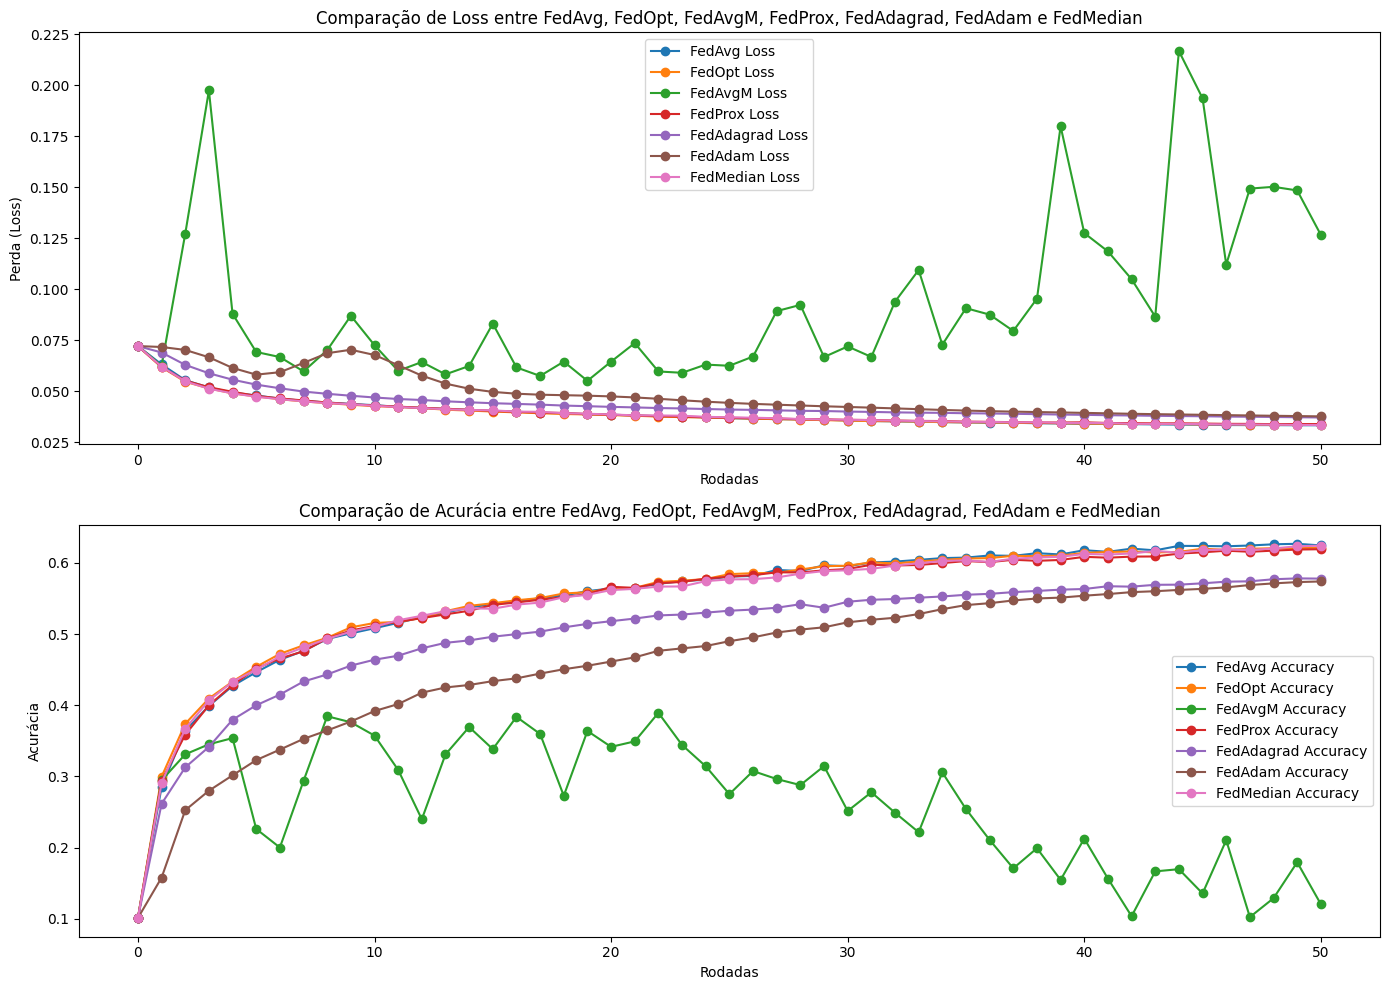

In [ ]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
for algorithm, data in results.items():
    plt.plot(data["rounds"], data["loss"], label=f'{algorithm} Loss', marker='o')
plt.xlabel('Rodadas')
plt.ylabel('Perda (Loss)')
plt.title('Comparação de Loss entre FedAvg, FedOpt, FedAvgM, FedProx, FedAdagrad, FedAdam e FedMedian')
plt.legend()

# Gráfico de Acurácia
plt.subplot(2, 1, 2)
for algorithm, data in results.items():
    plt.plot(data["rounds"], data["accuracy"], label=f'{algorithm} Accuracy', marker='o')
plt.xlabel('Rodadas')
plt.ylabel('Acurácia')
plt.title('Comparação de Acurácia entre FedAvg, FedOpt, FedAvgM, FedProx, FedAdagrad, FedAdam e FedMedian')
plt.legend()

plt.tight_layout()
plt.show()